# A comparison of the theoretical Eq (4) in the [blog](https://cyclostationary.blog/2016/08/22/cyclostationarity-of-digital-qam-and-psk/) and the Eq (10)(11) estimator in the [paper](https://www.mdpi.com/1424-8220/23/12/5735).

## Part1 Reproduce the Cumulants in table1 and table2 of the blog.

I'm trying to reproduce the Cumulants in table1 and table2 of the blog.

In [1]:
import math
import cmath
from functools import lru_cache

import numpy as np
import pandas as pd
from IPython.display import display

# ============================================================
# PART 1
# Build table1 / table2 / table3
# Save table3 into arrays / lists / dicts for later use
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.precision", 6)

# ----------------------------
# Helpers: normalization
# ----------------------------
def normalize_unit_variance(points):
    pts = np.asarray(points, dtype=np.complex128)
    pts = pts - pts.mean()
    var = np.mean(np.abs(pts) ** 2)
    return pts / np.sqrt(var)

# ----------------------------
# Helpers: set partitions
# ----------------------------
def _set_partitions(seq):
    if len(seq) == 1:
        return [[[seq[0]]]]

    first = seq[0]
    out = []
    seen = set()

    for part in _set_partitions(seq[1:]):
        cand = [[first]] + [b[:] for b in part]
        key = tuple(sorted(tuple(sorted(b)) for b in cand))
        if key not in seen:
            seen.add(key)
            out.append([list(b) for b in key])

        for i in range(len(part)):
            cand = [b[:] for b in part]
            cand[i] = [first] + cand[i]
            key = tuple(sorted(tuple(sorted(b)) for b in cand))
            if key not in seen:
                seen.add(key)
                out.append([list(b) for b in key])

    return out

@lru_cache(maxsize=None)
def partition_block_signatures(n_total, n_nonconj):
    idx = list(range(n_total))
    signatures = []

    for part in _set_partitions(idx):
        coeff = ((-1) ** (len(part) - 1)) * math.factorial(len(part) - 1)
        block_sig = []
        for block in part:
            p = sum(1 for j in block if j < n_nonconj)
            q = len(block) - p
            block_sig.append((p, q))
        signatures.append((coeff, tuple(sorted(block_sig))))

    return tuple(signatures)

# ----------------------------
# Moments and cumulants
# ----------------------------
def mixed_moment(points, p, q):
    pts = np.asarray(points, dtype=np.complex128)
    return np.mean((pts ** p) * (np.conj(pts) ** q))

def mixed_cumulant(points, n, m):
    n_nonconj = n - m
    cache_mom = {}
    out = 0.0 + 0.0j

    for coeff, blocks in partition_block_signatures(n, n_nonconj):
        prod = 1.0 + 0.0j
        for p, q in blocks:
            key = (p, q)
            if key not in cache_mom:
                cache_mom[key] = mixed_moment(points, p, q)
            prod *= cache_mom[key]
        out += coeff * prod

    if abs(out.imag) < 1e-12:
        out = out.real + 0j
    if abs(out.real) < 1e-12:
        out = 0.0 + 1j * out.imag
    return out

# ----------------------------
# Constellation definitions
# ----------------------------
const_real = {
    "BPSK": [-1, +1],
    "4ASK": [-3, -1, +1, +3],
    "8ASK": [-7, -5, -3, -1, +1, +3, +5, +7],
}

const_complex_raw = {
    "BPSK": [-1, +1],
    "QPSK": [1, 1j, -1, -1j],   # Chad blog's QPSK definition
    "8PSK": [cmath.exp(1j * 2 * math.pi * k / 8) for k in range(8)],
    "MPSK, M > 8": [cmath.exp(1j * 2 * math.pi * k / 16) for k in range(16)],
    "4QAM": [1 + 1j, 1 - 1j, -1 + 1j, -1 - 1j],
    "8QAM": [1, -1, 1j, -1j, 1 + 1j, 1 - 1j, -1 + 1j, -1 - 1j],
    "16QAM": [x + 1j * y for x in [-3, -1, 1, 3] for y in [-3, -1, 1, 3]],
    "32QAM": [x + 1j * y
              for x in [-5, -3, -1, 1, 3, 5]
              for y in [-5, -3, -1, 1, 3, 5]
              if not (abs(x) == 5 and abs(y) == 5)],
    "64QAM": [x + 1j * y
              for x in [-7, -5, -3, -1, 1, 3, 5, 7]
              for y in [-7, -5, -3, -1, 1, 3, 5, 7]],
    "128QAM": [x + 1j * y
               for x in [-11, -9, -7, -5, -3, -1, 1, 3, 5, 7, 9, 11]
               for y in [-11, -9, -7, -5, -3, -1, 1, 3, 5, 7, 9, 11]
               if not (abs(x) in [9, 11] and abs(y) in [9, 11])],
    "256QAM": [x + 1j * y
               for x in range(-15, 16, 2)
               for y in range(-15, 16, 2)],
}

const_real = {k: normalize_unit_variance(v) for k, v in const_real.items()}
const_complex = {k: normalize_unit_variance(v) for k, v in const_complex_raw.items()}

# ============================================================
# Table 1
# ============================================================
orders_real = [2, 4, 6, 8, 10]
rows_t1 = []

for name, pts in const_real.items():
    moments = [mixed_moment(pts, n, 0).real for n in orders_real]
    cumulants = [mixed_cumulant(pts, n, 0).real for n in orders_real]
    rows_t1.append([name, "M"] + moments)
    rows_t1.append([name, "C"] + cumulants)

table1 = pd.DataFrame(rows_t1, columns=["Constellation", "M/C", 2, 4, 6, 8, 10])

# ============================================================
# Table 2
# ============================================================
paired_specs = [
    ("C(4,0)=C(4,4)",   4,  [0, 4]),
    ("C(4,2)",          4,  [2]),
    ("C(6,1)=C(6,5)",   6,  [1, 5]),
    ("C(6,3)",          6,  [3]),
    ("C(8,0)=C(8,8)",   8,  [0, 8]),
    ("C(8,2)=C(8,6)",   8,  [2, 6]),
    ("C(8,4)",          8,  [4]),
    ("C(10,1)=C(10,9)", 10, [1, 9]),
    ("C(10,3)=C(10,7)", 10, [3, 7]),
    ("C(10,5)",         10, [5]),
]

table2_order = [
    "BPSK",
    "QPSK",
    "8PSK",
    "MPSK, M > 8",
    "4QAM",
    "8QAM",
    "16QAM",
    "32QAM",
    "64QAM",
    "128QAM",
    "256QAM",
]

rows_t2 = []
for name in table2_order:
    pts = const_complex[name]
    row = [name]
    for label, n, m_list in paired_specs:
        vals = [mixed_cumulant(pts, n, m).real for m in m_list]
        row.append(vals[0])
    rows_t2.append(row)

table2 = pd.DataFrame(rows_t2, columns=["PDF"] + [x[0] for x in paired_specs])

# ============================================================
# Table 3: full 24 C_a(n,m)
# ============================================================
full_nm = (
    [(2, m) for m in range(3)] +
    [(4, m) for m in range(5)] +
    [(6, m) for m in range(7)] +
    [(8, m) for m in range(9)]
)

table3_cols = [f"C({n},{m})" for (n, m) in full_nm]

table3_order = [
    "BPSK",
    "QPSK",
    "8PSK",
    "MPSK, M > 8",
    "4QAM",
    "8QAM",
    "16QAM",
    "32QAM",
    "64QAM",
    "128QAM",
    "256QAM",
]

rows_t3 = []
for name in table3_order:
    pts = const_complex[name]
    vals = [mixed_cumulant(pts, n, m).real for (n, m) in full_nm]
    rows_t3.append([name] + vals)

table3 = pd.DataFrame(rows_t3, columns=["PDF"] + table3_cols)

# ============================================================
# Save table3 for later use
# ============================================================
table3_pdf_list = table3["PDF"].tolist()
table3_col_labels = table3_cols[:]                              # list[str], len=24
table3_value_array = table3[table3_cols].to_numpy(dtype=float) # np.ndarray, shape=(11,24)
table3_value_list = table3[table3_cols].values.tolist()        # list[list]

# PDF -> 24-value row list
table3_row_list_dict = {
    pdf: table3.loc[table3["PDF"] == pdf, table3_cols].iloc[0].tolist()
    for pdf in table3_pdf_list
}

# PDF -> {(n,m): value}
table3_row_nm_dict = {
    pdf: {nm: val for nm, val in zip(full_nm, table3_row_list_dict[pdf])}
    for pdf in table3_pdf_list
}

# Direct exports
table3_bpsk_array = np.array(table3_row_list_dict["BPSK"], dtype=float)
table3_qpsk_array = np.array(table3_row_list_dict["QPSK"], dtype=float)

table3_bpsk_nm_dict = table3_row_nm_dict["BPSK"]
table3_qpsk_nm_dict = table3_row_nm_dict["QPSK"]

# ============================================================
# Rounded display copies
# ============================================================
table1_disp = table1.copy()
for c in [2, 4, 6, 8, 10]:
    table1_disp[c] = table1_disp[c].map(lambda x: round(float(x), 2))

table2_disp = table2.copy()
for c in table2_disp.columns[1:]:
    table2_disp[c] = table2_disp[c].map(lambda x: round(float(x), 2))

table3_disp = table3.copy()
for c in table3_disp.columns[1:]:
    table3_disp[c] = table3_disp[c].map(lambda x: round(float(x), 2))

# ============================================================
# Display
# ============================================================
print("Table 1")
display(table1_disp)

print("\nTable 2")
display(table2_disp)

print("\nTable 3")
display(table3_disp)


Table 1


,Constellation,M/C,2,4,6,8,10
0,BPSK,M,1.0,1.00,1.00,1.00,1.00
1,BPSK,C,1.0,-2.00,16.00,-272.00,7936.00
2,4ASK,M,1.0,1.64,2.92,5.25,9.45
3,4ASK,C,1.0,-1.36,8.32,-111.85,2603.01
4,8ASK,M,1.0,1.76,3.62,7.92,17.89
5,8ASK,C,1.0,-1.24,7.19,-92.02,2039.53



Table 2


,PDF,"C(4,0)=C(4,4)","C(4,2)","C(6,1)=C(6,5)","C(6,3)","C(8,0)=C(8,8)","C(8,2)=C(8,6)","C(8,4)","C(10,1)=C(10,9)","C(10,3)=C(10,7)","C(10,5)"
0,BPSK,-2.00,-2.00,16.00,16.00,-272.00,-272.00,-272.00,7936.00,7936.00,7936.00
1,QPSK,1.00,-1.00,-4.00,4.00,-34.00,34.00,-34.00,496.00,-496.00,496.00
2,8PSK,0.00,-1.00,0.00,4.00,1.00,0.00,-33.00,-8.00,0.00,456.00
3,"MPSK, M > 8",0.00,-1.00,0.00,4.00,0.00,0.00,-33.00,0.00,0.00,456.00
4,4QAM,-1.00,-1.00,4.00,4.00,-34.00,-34.00,-34.00,496.00,496.00,496.00
5,8QAM,-0.67,-0.89,2.30,3.33,-13.88,-17.93,-26.32,179.95,244.77,351.80
6,16QAM,-0.68,-0.68,2.08,2.08,-13.98,-13.98,-13.98,162.69,162.69,162.69
7,32QAM,-0.19,-0.69,0.57,2.11,-1.99,-3.84,-13.79,18.92,44.93,152.74
8,64QAM,-0.62,-0.62,1.80,1.80,-11.50,-11.50,-11.50,127.47,127.47,127.47
9,128QAM,-0.18,-0.66,0.53,1.96,-1.81,-3.48,-12.49,16.72,39.72,135.00



Table 3


,PDF,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)","C(8,0)","C(8,1)","C(8,2)","C(8,3)","C(8,4)","C(8,5)","C(8,6)","C(8,7)","C(8,8)"
0,BPSK,1.0,1.0,1.0,-2.00,-2.0,-2.00,-2.0,-2.00,16.0,16.00,16.0,16.00,16.0,16.00,16.0,-272.00,-272.0,-272.00,-272.0,-272.00,-272.0,-272.00,-272.0,-272.00
1,QPSK,0.0,1.0,0.0,1.00,0.0,-1.00,0.0,1.00,0.0,-4.00,0.0,4.00,0.0,-4.00,0.0,-34.00,0.0,34.00,0.0,-34.00,0.0,34.00,0.0,-34.00
2,8PSK,0.0,1.0,0.0,0.00,0.0,-1.00,0.0,0.00,0.0,0.00,0.0,4.00,0.0,0.00,0.0,1.00,0.0,0.00,0.0,-33.00,0.0,0.00,0.0,1.00
3,"MPSK, M > 8",0.0,1.0,0.0,0.00,0.0,-1.00,0.0,0.00,0.0,0.00,0.0,4.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,-33.00,0.0,0.00,0.0,0.00
4,4QAM,0.0,1.0,0.0,-1.00,0.0,-1.00,0.0,-1.00,0.0,4.00,0.0,4.00,0.0,4.00,0.0,-34.00,0.0,-34.00,0.0,-34.00,0.0,-34.00,0.0,-34.00
5,8QAM,0.0,1.0,0.0,-0.67,0.0,-0.89,0.0,-0.67,0.0,2.30,0.0,3.33,0.0,2.30,0.0,-13.88,0.0,-17.93,0.0,-26.32,0.0,-17.93,0.0,-13.88
6,16QAM,0.0,1.0,0.0,-0.68,0.0,-0.68,0.0,-0.68,0.0,2.08,0.0,2.08,0.0,2.08,0.0,-13.98,0.0,-13.98,0.0,-13.98,0.0,-13.98,0.0,-13.98
7,32QAM,0.0,1.0,0.0,-0.19,0.0,-0.69,0.0,-0.19,0.0,0.57,0.0,2.11,0.0,0.57,0.0,-1.99,0.0,-3.84,0.0,-13.79,0.0,-3.84,0.0,-1.99
8,64QAM,0.0,1.0,0.0,-0.62,0.0,-0.62,0.0,-0.62,0.0,1.80,0.0,1.80,0.0,1.80,0.0,-11.50,0.0,-11.50,0.0,-11.50,0.0,-11.50,0.0,-11.50
9,128QAM,0.0,1.0,0.0,-0.18,0.0,-0.66,0.0,-0.18,0.0,0.53,0.0,1.96,0.0,0.53,0.0,-1.81,0.0,-3.48,0.0,-12.49,0.0,-3.48,0.0,-1.81


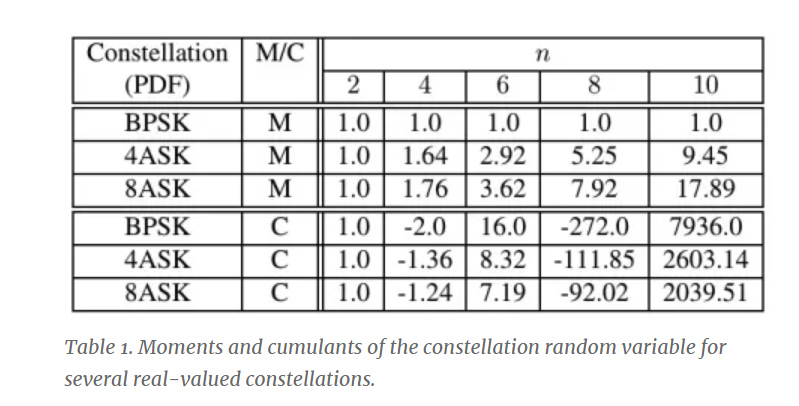
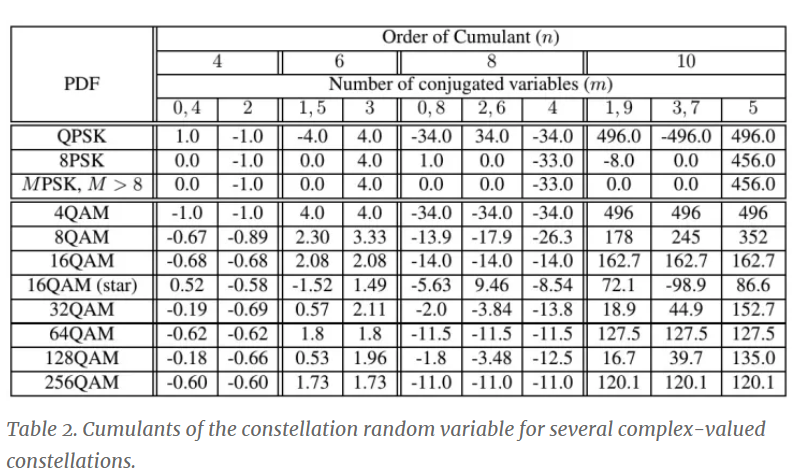

As we can see, my calculation results are almost identical to those in the blog.

## Part 2 Using SQRC signal (rolloff = 0.35) to compare the theoretical calculations with the Eq10,11 estimators.

## Part2.1 Theoretical calculations

We assume a textbook linear digital modulation model with IID symbols and a real-valued pulse-shaping function $p(t)$. We also set all delay variables to zero according to the paper, i.e., $\tau_1=\cdots=\tau_n=0$, so the cyclic cumulants are evaluated at zero lag.

Since $p(t)\in\mathbb{R}$, we have $p^*(t)=p(t)$. Therefore, the conjugated and non-conjugated pulse terms become identical, and the pulse-dependent product simplifies to $p(t)^n$. Under these assumptions, the theoretical cyclic cumulant reduces to a symbol-cumulant term $C_a(n,m)$ multiplied by the Fourier integral of $p(t)^n$ at cycle frequency $\alpha$.

$$
C_{s_{BB}}^\alpha(\tau;n,m)
=
\frac{C_a(n,m)}{T_0}
\int
\left[
\prod_{j=1}^{n} p^{(*)_j}(t+\tau_j)
\right]
e^{-i2\pi\alpha t}\,dt
\;\xrightarrow{\;\tau_1=\cdots=\tau_n=0\;}
\frac{C_a(n,m)}{T_0}
\int
\left[
\prod_{j=1}^{n} p^{(*)_j}(t)
\right]
e^{-i2\pi\alpha t}\,dt
$$

$$
\;\xrightarrow{\;p(t)\in\mathbb{R}\;\Rightarrow\;p^*(t)=p(t)\;}
\frac{C_a(n,m)}{T_0}
\int
\left[
\prod_{j=1}^{n} p(t)
\right]
e^{-i2\pi\alpha t}\,dt
=
\frac{C_a(n,m)}{T_0}
\int
p(t)^n\,e^{-i2\pi\alpha t}\,dt
$$



In [2]:
import math
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0) Check input
# ============================================================
if "table3_row_nm_dict" not in globals():
    raise RuntimeError("Missing required object: table3_row_nm_dict")

# ============================================================
# 1) Basic settings
# ============================================================
EPS = 1e-12

formula4_params = {
    "T0": 17,
    "f0": 1.7859487009e-04,
    "beta": 0.35, #rolloff = 0.35
    "span_symbols": 12,
    "pulse_sps": 128,
}

# The 15 (n,m) combinations used in the paper setting:
# n = 2,4,6 and m = 0...n
NM_15 = (
    [(2, m) for m in range(3)] +
    [(4, m) for m in range(5)] +
    [(6, m) for m in range(7)]
)

COL_LABELS_15 = [f"C({n},{m})" for (n, m) in NM_15]
# K_LIST:
# Harmonic index list k = -5,...,5, giving 11 rows in the matrix.
K_LIST = list(range(-5, 6))

# ============================================================
# 2) Constellations (only BPSK / QPSK needed here)
# ============================================================
def normalize_unit_variance(points):
    pts = np.asarray(points, dtype=np.complex128)
    pts = pts - pts.mean()
    var = np.mean(np.abs(pts) ** 2)
    return pts / np.sqrt(var + EPS)

CONSTELLATIONS = {
    "BPSK": normalize_unit_variance([-1, +1]),
    "QPSK": normalize_unit_variance([1, 1j, -1, -1j]),
}

# ============================================================
# 3) SRRC pulse + theory matrix
# ============================================================
def srrc_pulse(t, T0=1.0, beta=0.35):
    """
    Generate the square-root raised cosine (SRRC) pulse p(t).

    Purpose:
    This function computes the SRRC pulse samples at the time points t.
    The SRRC pulse is used as the pulse-shaping function in the theoretical
    cyclic cumulant calculation.

    Parameters:
    - t:
        Time samples where the pulse is evaluated.
    - T0:
        Symbol period.
    - beta:
        Roll-off factor of the SRRC pulse.
    Output:
    - p:
        Real-valued SRRC pulse samples with the same shape as t.
    """
    t = np.asarray(t, dtype=float)
    p = np.zeros_like(t, dtype=float)
    eps = 1e-12

    idx_generic = np.ones_like(t, dtype=bool)

    idx0 = np.abs(t) < eps
    if np.any(idx0):
        p[idx0] = (1.0 / np.sqrt(T0)) * (1 + beta * (4 / np.pi - 1))
        idx_generic[idx0] = False

    if beta > 0:
        tsing = T0 / (4 * beta)
        idxs = np.abs(np.abs(t) - tsing) < 1e-10
        if np.any(idxs):
            p[idxs] = (
                (beta / np.sqrt(2 * T0))
                * (
                    (1 + 2 / np.pi) * np.sin(np.pi / (4 * beta))
                    + (1 - 2 / np.pi) * np.cos(np.pi / (4 * beta))
                )
            )
            idx_generic[idxs] = False

    tg = t[idx_generic]
    if tg.size > 0:
        x = tg / T0
        numerator = (
            np.cos((1 + beta) * np.pi * x)
            + np.sin((1 - beta) * np.pi * x) / (4 * beta * x)
        )
        denominator = 1 - (4 * beta * x) ** 2
        p[idx_generic] = (4 * beta / (np.pi * np.sqrt(T0))) * (numerator / denominator)

    return p


def build_unit_power_srrc(T0=8.0, beta=0.35, span_symbols=12, pulse_sps=128):
    """
    Build a finite-length SRRC pulse with unit-power normalization.

    Purpose:
    This function creates sampled SRRC pulse values on a dense time grid
    and rescales the pulse so that its energy satisfies
        ∫ |p(t)|^2 dt = T0.
    This normalization is used before the theoretical cyclic cumulant calculation.

    Parameters:
    - T0:
        Symbol period.
    - beta:
        Roll-off factor of the SRRC pulse.
    - span_symbols:
        Total pulse length measured in number of symbols.
    - pulse_sps:
        Number of pulse samples per symbol.
    Output:
    - t:
        Time grid for the pulse samples.
    - p:
        Unit-power SRRC pulse samples.
    - dt:
        Time-step used for numerical integration.
    """
    dt = T0 / pulse_sps
    t = np.arange(-span_symbols * T0 / 2, span_symbols * T0 / 2 + dt, dt)
    p = srrc_pulse(t, T0=T0, beta=beta)

    # scale so that integral |p(t)|^2 dt = T0
    energy = np.sum(np.abs(p) ** 2) * dt
    scale = np.sqrt(T0 / (energy + EPS))
    p = p * scale
    return t, p, dt


def pulse_integral_for_order(alpha, n, t, p, dt):
    """
    Compute the pulse-dependent integral for the theoretical cyclic cumulant.

    Purpose:
    This function numerically evaluates
        ∫ p(t)^n exp(-j 2π α t) dt
    for a given order n and cycle frequency alpha.

    Parameters:
    - alpha:
        Cycle frequency used in the theoretical formula.
    - n:
        Cumulant order.
    - t:
        Time grid of the pulse samples.
    - p:
        Pulse samples p(t).
    - dt:
        Time-step used for numerical integration.
    Output:
    - complex scalar:
        Numerical approximation of the pulse integral.
    """
    integrand = (p ** n) * np.exp(-1j * 2 * np.pi * alpha * t)
    return np.sum(integrand) * dt


def build_theoretical_cc_matrix_from_table3(pdf_name, T0=8.0, f0=0.037, beta=0.35,
                                            span_symbols=12, pulse_sps=128):
    """
    Build the full theoretical 11x15 cyclic cumulant matrix.

    Purpose:
    This function computes the theoretical cyclic cumulant magnitudes for
    one modulation type using:
    - symbol cumulants C_a(n,m) from table3_row_nm_dict
    - the SRRC pulse integral
    - the cycle frequency formula alpha = (n - 2m) f0 + k / T0

    Parameters:
    - pdf_name:
        Name of the modulation entry in table3_row_nm_dict, such as
        "BPSK", "QPSK", "8PSK", "16QAM", etc.
    - T0:
        Symbol period.
    - f0:
        Carrier frequency offset.
    - beta:
        SRRC roll-off factor.
    - span_symbols:
        Pulse span used to build the SRRC pulse.
    - pulse_sps:
        Pulse samples per symbol.
    Output:
    - dictionary containing:
        "pdf_name": modulation name
        "matrix_complex": full complex-valued theoretical matrix
        "matrix_abs": magnitude of the theoretical matrix
        "k_list": row labels
        "col_labels_15": column labels
    """
    if pdf_name not in table3_row_nm_dict:
        raise ValueError(f"{pdf_name} not found in table3_row_nm_dict")

    Ca_lookup = table3_row_nm_dict[pdf_name]

    t, p, dt = build_unit_power_srrc(
        T0=T0, beta=beta, span_symbols=span_symbols, pulse_sps=pulse_sps
    )

    pulse_integral_cache = {}
    M = np.zeros((len(K_LIST), len(NM_15)), dtype=np.complex128)

    for i_k, k in enumerate(K_LIST):
        for i_col, (n, m) in enumerate(NM_15):
            alpha = (n - 2 * m) * f0 + (k / T0)

            cache_key = (n, alpha)
            if cache_key not in pulse_integral_cache:
                pulse_integral_cache[cache_key] = pulse_integral_for_order(alpha, n, t, p, dt)

            In_alpha = pulse_integral_cache[cache_key]
            Ca_nm = Ca_lookup[(n, m)]
            M[i_k, i_col] = (Ca_nm / T0) * In_alpha

    return {
        "pdf_name": pdf_name,
        "matrix_complex": M,
        "matrix_abs": np.abs(M),
        "k_list": K_LIST,
        "col_labels_15": COL_LABELS_15,
    }


# ============================================================
# 4) Signal synthesis for estimator input
# ============================================================
def normalize_signal_rms(x, eps=1e-12):
    """
    Normalize a complex signal by its RMS value.

    Purpose:
    This function rescales the input signal so that its RMS magnitude becomes 1.
    This gives a consistent signal power before estimation.

    Parameters:
    - x:
        Complex input signal.
    - eps:
        Small number to avoid division by zero.
    Output:
    - normalized complex signal with unit RMS.
    """
    x = np.asarray(x, dtype=np.complex128)
    rms = np.sqrt(np.mean(np.abs(x) ** 2))
    return x / (rms + eps)


def synthesize_iid_linear_mod_signal(constellation_name, T0, f0, beta=0.35,
                                     n_samples=32768, span_symbols=12, pulse_sps=128,
                                     seed=0):
    """
    Synthesize a textbook IID linear modulation signal.

    Purpose:
    This function generates a simulated communication signal for
    estimation. The signal is formed by:
    - drawing IID symbols from a constellation
    - pulse-shaping them with an SRRC pulse
    - applying carrier frequency offset
    - normalizing the final signal power

    Parameters:
    - constellation_name:
        Name of the constellation in CONSTELLATIONS, such as "BPSK" or "QPSK".
    - T0:
        Symbol period.
    - f0:
        Carrier frequency offset.
    - beta:
        SRRC roll-off factor.
    - n_samples:
        Number of output signal samples.
    - span_symbols:
        Pulse span in symbols.
    - pulse_sps:
        Pulse samples per symbol.
    - seed:
        Random seed for reproducible symbol generation.
    Output:
    - x:
        Simulated complex baseband signal of length n_samples.
    """
    rng = np.random.default_rng(seed)

    if constellation_name not in CONSTELLATIONS:
        raise ValueError(f"Unknown constellation: {constellation_name}")
    a_const = np.asarray(CONSTELLATIONS[constellation_name], dtype=np.complex128)
    t_p, p, dt = build_unit_power_srrc(
        T0=T0, beta=beta, span_symbols=span_symbols, pulse_sps=pulse_sps
    )
    n_sym_margin = span_symbols + 4
    n_symbols = int(np.ceil(n_samples / T0)) + n_sym_margin
    a = rng.choice(a_const, size=n_symbols, replace=True)
    t = np.arange(n_samples, dtype=np.float64)
    x = np.zeros(n_samples, dtype=np.complex128)
    for k in range(n_symbols):
        x += a[k] * np.interp(
            t - k * T0,
            t_p,
            p,
            left=0.0,
            right=0.0
        )

    x = x * np.exp(1j * 2 * np.pi * f0 * t)
    x = normalize_signal_rms(x)
    return x

## Part2.2 Eq(10)(11) Estimators

### Part2.2.1 Set partitions for cumulant-moment relation

These two helper functions generate all distinct **set partitions** of an index set of size `n`. They are required because the cyclic cumulant is constructed from lower-order cyclic temporal moments through the **moment–cumulant relation**.

In the Ref.1, the temporal cumulant function is written as a sum over all distinct partitions of the index set, with coefficient

$$
h(p)=(-1)^{p-1}(p-1)!,
$$

and the same combinatorial structure also appears in the finite-time cyclic cumulant estimate. These helper functions implement exactly that partition bookkeeping in code. Their role is therefore foundational: they allow the code to expand the cumulant into the required signed combination of lower-order moment terms.


In [3]:

@lru_cache(maxsize=None)
def _set_partitions_tuple(n: int):
    if n == 0:
        return ((),)
    prev = _set_partitions_tuple(n - 1)
    out = []

    for p in prev:
        p_new = list(list(b) for b in p) + [[n - 1]]
        out.append(p_new)

        for i in range(len(p)):
            p2 = [list(b) for b in p]
            p2[i].append(n - 1)
            out.append(p2)

    seen = set()
    canon = []
    for p in out:
        blk_sorted = [tuple(sorted(b)) for b in p]
        blk_sorted = tuple(sorted(blk_sorted, key=lambda x: (len(x), x)))
        if blk_sorted not in seen:
            seen.add(blk_sorted)
            canon.append(blk_sorted)
    return tuple(canon)


def _set_partitions(n: int):
    return [[list(block) for block in part] for part in _set_partitions_tuple(n)]

### Part2.2.2 CTMF estimate (Ref.1 Eq. 10), $\tau = 0$

This is the code’s implementation of the **finite-time cyclic temporal moment function (CTMF)** at **delay vector $\tau=0$**.

For each order pair $(n,m)$, and for cycle-frequency indices $k=-K,\dots,K$, it evaluates

$$
\beta = (n-2m)f_0 + k/T_0,
$$

and then computes the finite-time moment sequence

$$
\hat{R}_x^\beta(\tau;n,m)
=
\frac{1}{T}
\int_0^T
\left[
\prod_{j=1}^{n} x^{(*)_j}(t+\tau_j)
\right]
e^{-i2\pi\beta t}\,dt
\;\xrightarrow{\;\tau=0\;}
\frac{1}{T}
\int_0^T
\left[
\prod_{j=1}^{n} x^{(*)_j}(t)
\right]
e^{-i2\pi\beta t}\,dt
\;\xrightarrow{\;\text{$m$ conjugated terms}\;}
\frac{1}{T}
\int_0^T
x(t)^{\,n-m}\,\overline{x(t)}^{\,m}
e^{-i2\pi\beta t}\,dt
\;\xrightarrow{\;\text{discrete-time}\;}
\frac{1}{N}
\sum_{\ell=0}^{N-1}
x(t_\ell)^{\,n-m}\,\overline{x(t_\ell)}^{\,m}
e^{-i2\pi\beta t_\ell}
$$
This corresponds directly to the Ref.1’s finite-time CTMF estimator, specialized to the case $\tau=0$. The Ref.1 states that the nonzero cycle frequencies are determined by the combination of CFO and symbol rate, and the code follows that formula explicitly by constructing `beta` from `f0`, `T0`, and integer harmonic index `k`.

This function is the first place where the truth-driven simplification becomes operational: since `f0` and `T0` are not blindly estimated here, the function receives them directly from the truth-label path.


In [4]:
def cyclic_moment_sequence_tau0(x, T0, f0, n, m, K, remove_mean=False):
    """
    Eq. (10) finite-time estimator at tau=0
    """
    x = np.asarray(x, dtype=np.complex128)
    if remove_mean:
        x = x - np.mean(x)

    N = x.size
    t = np.arange(N, dtype=np.float64)

    Rs = 1.0 / T0
    ks = np.arange(-K, K + 1, dtype=np.float64)
    beta = (n - 2 * m) * f0 + ks * Rs

    u = (x ** (n - m)) * (np.conj(x) ** m)

    E = np.exp(-1j * 2 * np.pi * beta[:, None] * t[None, :])
    Mseq = (E @ u) / N
    return Mseq


### Part2.2.3 CC estimate (Ref.1 Eq. 11), using partition formula

This function is the core implementation of the **finite-time cyclic cumulant estimator**.

Its logic is:

1. determine which variable slots are conjugated,
2. enumerate all distinct set partitions of order `n`,
3. determine which lower-order CTMFs are needed,
4. compute those CTMFs,
5. combine them using the partition coefficients
   $$
   (-1)^{p-1}(p-1)!,
   $$
6. enforce the cycle-frequency summation rule by convolution over the \(k\)-index.

This is the code realization of the Ref.1’s cyclic cumulant estimate:

$$
\hat{C}_x^\alpha(\tau;n,m)
=
\sum_{P_n}
\left[
h(p)
\sum_{\beta_1^\dagger=\alpha}
\prod_{j=1}^{p}
\hat{R}_{x_{\nu_j}}^{\beta_j}(\tau_{\nu_j};n_j,m_j)
\right].
$$

Thus, this function is the true mathematical center of the reproduction. If `cyclic_moment_sequence_tau0` computes the building blocks, then `cyclic_cumulant_sequence_tau0` assembles those blocks into the final cyclic cumulant sequence.

In [5]:

def _conv_k_sequences(seqs):
    out = np.array([1.0 + 0j], dtype=np.complex128)
    for s in seqs:
        out = np.convolve(out, s, mode="full")
    return out


def cyclic_cumulant_sequence_tau0(x, T0, f0, n, m, K, remove_mean=False):
    """
    Eq. (11) finite-time estimator at tau=0
    """
    Nvar = n

    is_conj = np.zeros(Nvar, dtype=np.int32)
    is_conj[(n - m):] = 1

    partitions = _set_partitions(Nvar)

    needed = set()
    for pi in partitions:
        for blk in pi:
            nb = len(blk)
            mb = int(np.sum(is_conj[np.array(blk, dtype=int)]))
            needed.add((nb, mb))

    Mcache = {}
    for (nb, mb) in needed:
        Mcache[(nb, mb)] = cyclic_moment_sequence_tau0(
            x=x, T0=T0, f0=f0, n=nb, m=mb, K=K, remove_mean=remove_mean
        )

    full_half = n * K
    center = full_half
    C_full = np.zeros((2 * full_half + 1,), dtype=np.complex128)

    for pi in partitions:
        p = len(pi)
        coef = ((-1) ** (p - 1)) * math.factorial(p - 1)

        seqs = []
        for blk in pi:
            nb = len(blk)
            mb = int(np.sum(is_conj[np.array(blk, dtype=int)]))
            seqs.append(Mcache[(nb, mb)])

        conv = _conv_k_sequences(seqs)
        conv_center = p * K

        lo = center - conv_center
        hi = center + conv_center + 1
        C_full[lo:hi] += coef * conv

    return C_full[center - K:center + K + 1]

## Part2.3 Plot and compare

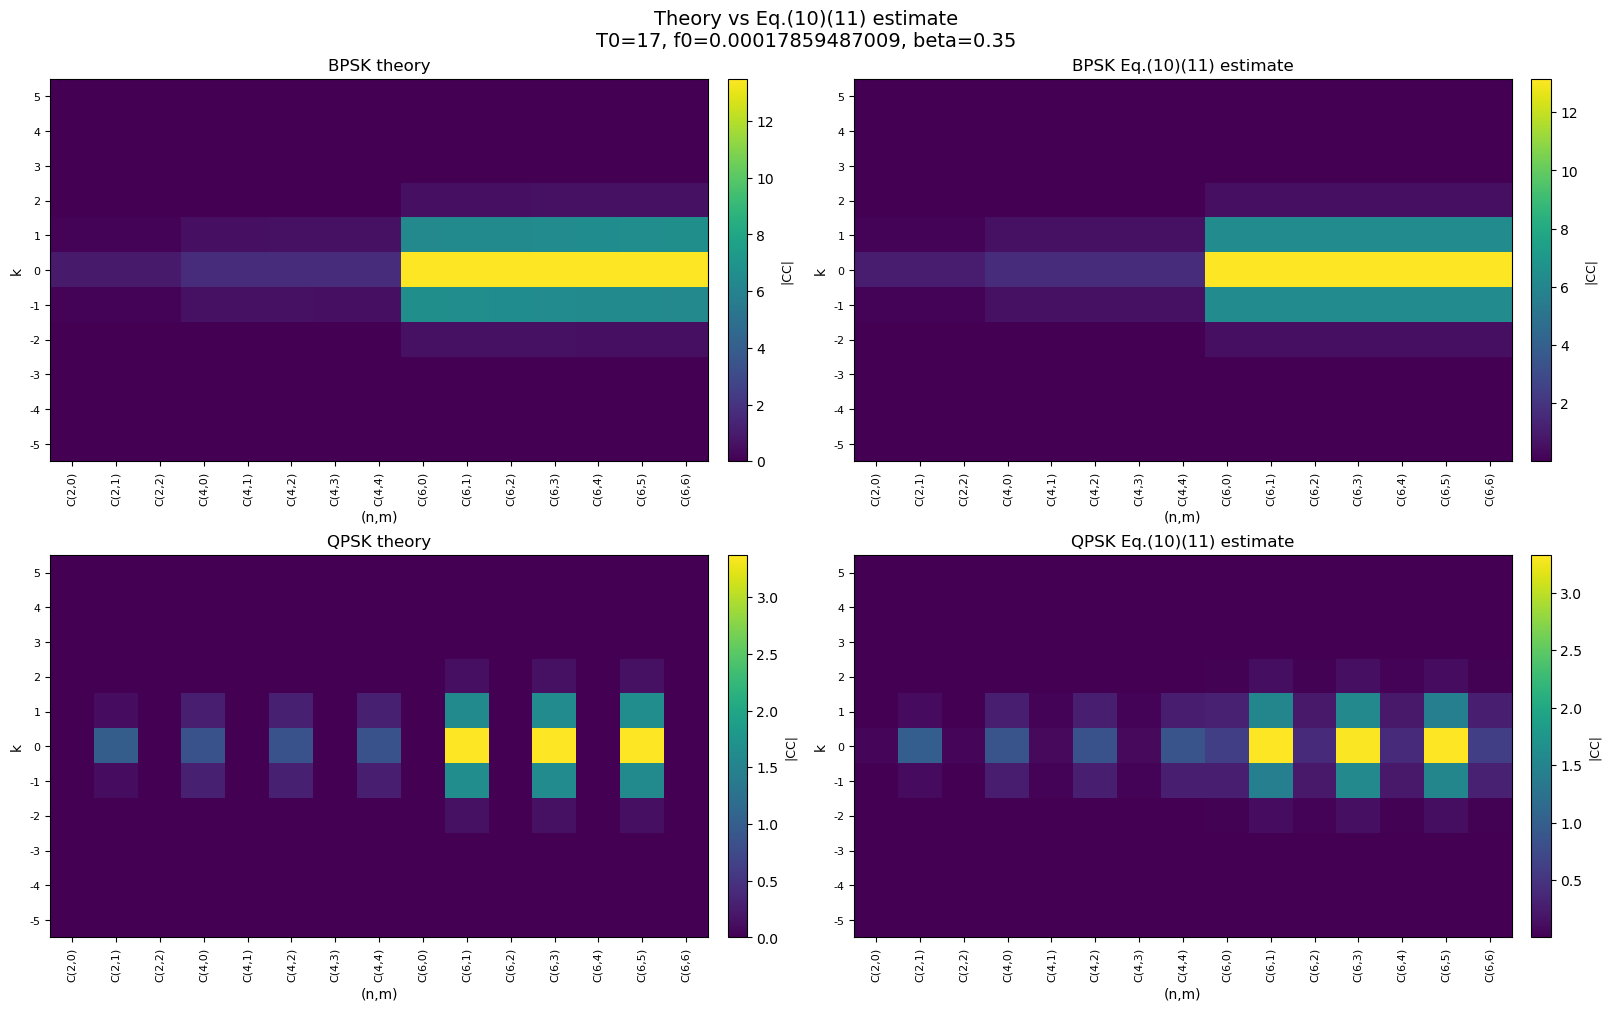


================ BPSK theory matrix =================


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)"
-5,0.000000,0.000000,0.000001,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-4,0.000001,0.000000,0.000001,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-3,0.000001,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002729,0.002589,0.002455,0.002327,0.002205,0.002088,0.001977
-2,0.000004,0.000002,0.000001,0.008297,0.007892,0.007503,0.007129,0.006769,0.623893,0.610932,0.598182,0.585641,0.573307,0.561179,0.549252
-1,0.116228,0.111420,0.106694,0.599997,0.591907,0.583866,0.575876,0.567937,6.692071,6.632932,6.573925,6.515053,6.456322,6.397738,6.339305
0,0.999876,1.000000,0.999876,1.699675,1.699873,1.699939,1.699873,1.699675,13.473735,13.475504,13.476566,13.476920,13.476566,13.475504,13.473735
1,0.106694,0.111420,0.116228,0.567937,0.575876,0.583866,0.591907,0.599997,6.339305,6.397738,6.456322,6.515053,6.573925,6.632932,6.692071
2,0.000001,0.000002,0.000004,0.006769,0.007129,0.007503,0.007892,0.008297,0.549252,0.561179,0.573307,0.585641,0.598182,0.610932,0.623893
3,0.000000,0.000000,0.000001,0.000000,0.000000,0.000000,0.000000,0.000000,0.001977,0.002088,0.002205,0.002327,0.002455,0.002589,0.002729
4,0.000001,0.000000,0.000001,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



================ BPSK Eq.(10)(11) estimate matrix =================


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)"
-5,0.000029,0.000029,0.000029,0.000149,0.000149,0.000149,0.000149,0.000149,0.001880,0.001880,0.001880,0.001880,0.001880,0.001880,0.001880
-4,0.000031,0.000031,0.000031,0.000185,0.000185,0.000185,0.000185,0.000185,0.002532,0.002532,0.002532,0.002532,0.002532,0.002532,0.002532
-3,0.000034,0.000034,0.000034,0.000210,0.000210,0.000210,0.000210,0.000210,0.004811,0.004811,0.004811,0.004811,0.004811,0.004811,0.004811
-2,0.000051,0.000051,0.000051,0.007284,0.007284,0.007284,0.007284,0.007284,0.560544,0.560544,0.560544,0.560544,0.560544,0.560544,0.560544
-1,0.108681,0.108681,0.108681,0.572166,0.572166,0.572166,0.572166,0.572166,6.324750,6.324750,6.324750,6.324750,6.324750,6.324750,6.324750
0,0.998125,0.998125,0.998125,1.679249,1.679249,1.679249,1.679249,1.679249,13.139486,13.139486,13.139486,13.139486,13.139486,13.139486,13.139486
1,0.108681,0.108681,0.108681,0.572166,0.572166,0.572166,0.572166,0.572166,6.324750,6.324750,6.324750,6.324750,6.324750,6.324750,6.324750
2,0.000051,0.000051,0.000051,0.007284,0.007284,0.007284,0.007284,0.007284,0.560544,0.560544,0.560544,0.560544,0.560544,0.560544,0.560544
3,0.000034,0.000034,0.000034,0.000210,0.000210,0.000210,0.000210,0.000210,0.004811,0.004811,0.004811,0.004811,0.004811,0.004811,0.004811
4,0.000031,0.000031,0.000031,0.000185,0.000185,0.000185,0.000185,0.000185,0.002532,0.002532,0.002532,0.002532,0.002532,0.002532,0.002532



================ BPSK absolute error =================


...

,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)"
-5,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
-4,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
-3,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000647,0.0,0.000582,0.0,0.000522,0.0
-2,0.0,0.000002,0.0,0.004149,0.0,0.003752,0.0,0.003384,0.0,0.152733,0.0,0.146410,0.0,0.140295,0.0
-1,0.0,0.111420,0.0,0.299998,0.0,0.291933,0.0,0.283969,0.0,1.658233,0.0,1.628763,0.0,1.599435,0.0
0,0.0,1.000000,0.0,0.849838,0.0,0.849969,0.0,0.849838,0.0,3.368876,0.0,3.369230,0.0,3.368876,0.0
1,0.0,0.111420,0.0,0.283969,0.0,0.291933,0.0,0.299998,0.0,1.599435,0.0,1.628763,0.0,1.658233,0.0
2,0.0,0.000002,0.0,0.003384,0.0,0.003752,0.0,0.004149,0.0,0.140295,0.0,0.146410,0.0,0.152733,0.0
3,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000522,0.0,0.000582,0.0,0.000647,0.0
4,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0



================ QPSK Eq.(10)(11) estimate matrix =================


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)"
-5,0.000008,0.000020,0.000022,0.000013,0.000031,0.000073,0.000050,0.000028,0.000220,0.000178,0.000206,0.000535,0.000321,0.000224,0.000397
-4,0.000012,0.000026,0.000028,0.000022,0.000042,0.000101,0.000069,0.000039,0.000355,0.000286,0.000299,0.000794,0.000480,0.000335,0.000600
-3,0.000023,0.000032,0.000042,0.000033,0.000067,0.000128,0.000099,0.000058,0.001168,0.000680,0.000647,0.001233,0.000615,0.000280,0.000718
-2,0.000031,0.000061,0.000059,0.001858,0.000908,0.003256,0.000827,0.001981,0.013864,0.108447,0.026358,0.134122,0.024573,0.119739,0.025214
-1,0.004686,0.103882,0.004464,0.249419,0.036247,0.280689,0.035820,0.274273,0.284618,1.440840,0.233886,1.568615,0.229593,1.527383,0.304273
0,0.055156,0.999342,0.055156,0.859444,0.081402,0.842246,0.081402,0.859444,0.613413,3.327014,0.408981,3.309660,0.408981,3.327014,0.613413
1,0.004464,0.103882,0.004686,0.274273,0.035820,0.280689,0.036247,0.249419,0.304273,1.527383,0.229593,1.568615,0.233886,1.440840,0.284618
2,0.000059,0.000061,0.000031,0.001981,0.000827,0.003256,0.000908,0.001858,0.025214,0.119739,0.024573,0.134122,0.026358,0.108447,0.013864
3,0.000042,0.000032,0.000023,0.000058,0.000099,0.000128,0.000067,0.000033,0.000718,0.000280,0.000615,0.001233,0.000647,0.000680,0.001168
4,0.000028,0.000026,0.000012,0.000039,0.000069,0.000101,0.000042,0.000022,0.000600,0.000335,0.000480,0.000794,0.000299,0.000286,0.000355



================ QPSK absolute error =================


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)"
-5,0.000008,0.000020,0.000022,0.000013,0.000031,0.000073,0.000050,0.000028,0.000220,0.000178,0.000206,0.000535,0.000321,0.000224,0.000397
-4,0.000012,0.000026,0.000028,0.000022,0.000042,0.000101,0.000069,0.000039,0.000355,0.000286,0.000299,0.000794,0.000480,0.000335,0.000600
-3,0.000023,0.000032,0.000042,0.000033,0.000067,0.000128,0.000099,0.000058,0.001168,0.000033,0.000647,0.000651,0.000615,0.000242,0.000718
-2,0.000031,0.000059,0.000059,0.002291,0.000908,0.000496,0.000827,0.001403,0.013864,0.044286,0.026358,0.012288,0.024573,0.020556,0.025214
-1,0.004686,0.007538,0.004464,0.050579,0.036247,0.011244,0.035820,0.009696,0.284618,0.217393,0.233886,0.060148,0.229593,0.072052,0.304273
0,0.055156,0.000658,0.055156,0.009606,0.081402,0.007723,0.081402,0.009606,0.613413,0.041862,0.408981,0.059570,0.408981,0.041862,0.613413
1,0.004464,0.007538,0.004686,0.009696,0.035820,0.011244,0.036247,0.050579,0.304273,0.072052,0.229593,0.060148,0.233886,0.217393,0.284618
2,0.000059,0.000059,0.000031,0.001403,0.000827,0.000496,0.000908,0.002291,0.025214,0.020556,0.024573,0.012288,0.026358,0.044286,0.013864
3,0.000042,0.000032,0.000023,0.000058,0.000099,0.000128,0.000067,0.000033,0.000718,0.000242,0.000615,0.000651,0.000647,0.000033,0.001168
4,0.000028,0.000026,0.000012,0.000039,0.000069,0.000101,0.000042,0.000022,0.000600,0.000335,0.000480,0.000794,0.000299,0.000286,0.000355


In [6]:
def build_estimated_cc_matrix_11x15_from_signal(x, T0, f0, remove_mean=False, max_k=5):
    #x = normalize_signal_rms(x)

    M = np.zeros((len(K_LIST), len(NM_15)), dtype=np.complex128)
    for i_col, (n, m) in enumerate(NM_15):
        M[:, i_col] = cyclic_cumulant_sequence_tau0(
            x=x,
            T0=T0,
            f0=f0,
            n=n,
            m=m,
            K=max_k,
            remove_mean=remove_mean
        )

    return {
        "matrix_complex": M,
        "matrix_abs": np.abs(M),
        "k_list": K_LIST,
        "col_labels_15": COL_LABELS_15,
    }



# ============================================================
# 6) Build BPSK / QPSK theory and estimate
# ============================================================
def build_case(pdf_name, seed=0, n_samples=32768):
    theory = build_theoretical_cc_matrix_from_table3(
        pdf_name=pdf_name,
        T0=formula4_params["T0"],
        f0=formula4_params["f0"],
        beta=formula4_params["beta"],
        span_symbols=formula4_params["span_symbols"],
        pulse_sps=formula4_params["pulse_sps"],
    )

    x = synthesize_iid_linear_mod_signal(
        constellation_name=pdf_name,
        T0=formula4_params["T0"],
        f0=formula4_params["f0"],
        beta=formula4_params["beta"],
        n_samples=n_samples,
        span_symbols=formula4_params["span_symbols"],
        pulse_sps=formula4_params["pulse_sps"],
        seed=seed,
    )

    estimate = build_estimated_cc_matrix_11x15_from_signal(
        x=x,
        T0=formula4_params["T0"],
        f0=formula4_params["f0"],
        remove_mean=False,
        max_k=5,
    )

    return {
        "pdf_name": pdf_name,
        "theory": theory,
        "estimate": estimate,
        "signal": x,
    }

bpsk_case = build_case("BPSK", seed=0, n_samples=32768)
qpsk_case = build_case("QPSK", seed=1, n_samples=32768)

# ============================================================
# 7) 2x2 comparison figure
# ============================================================
def plot_2x2_comparison(bpsk_case, qpsk_case):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

    panels = [
        (0, 0, bpsk_case["theory"]["matrix_abs"],  "BPSK theory"),
        (0, 1, bpsk_case["estimate"]["matrix_abs"], "BPSK Eq.(10)(11) estimate"),
        (1, 0, qpsk_case["theory"]["matrix_abs"],  "QPSK theory"),
        (1, 1, qpsk_case["estimate"]["matrix_abs"], "QPSK Eq.(10)(11) estimate"),
    ]

    for r, c, M, title in panels:
        ax = axes[r, c]
        im = ax.imshow(M, aspect="auto", origin="lower")
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("(n,m)")
        ax.set_ylabel("k")
        ax.set_xticks(np.arange(len(COL_LABELS_15)))
        ax.set_xticklabels(COL_LABELS_15, rotation=90, fontsize=8)
        ax.set_yticks(np.arange(len(K_LIST)))
        ax.set_yticklabels(K_LIST, fontsize=8)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cbar.set_label("|CC|", fontsize=9)

    fig.suptitle(
        f"Theory vs Eq.(10)(11) estimate\n"
        f"T0={formula4_params['T0']}, f0={formula4_params['f0']}, beta={formula4_params['beta']}",
        fontsize=14
    )
    plt.show()

plot_2x2_comparison(bpsk_case, qpsk_case)

# ============================================================
# 8) Numeric matrices
# ============================================================
def matrix_to_df(case_dict, which="theory", decimals=6):
    M = case_dict[which]["matrix_abs"]
    return pd.DataFrame(M, index=K_LIST, columns=COL_LABELS_15).round(decimals)

BPSK_theory_df   = matrix_to_df(bpsk_case, "theory", decimals=6)
BPSK_estimate_df = matrix_to_df(bpsk_case, "estimate", decimals=6)
QPSK_theory_df   = matrix_to_df(qpsk_case, "theory", decimals=6)
QPSK_estimate_df = matrix_to_df(qpsk_case, "estimate", decimals=6)
BPSK_abs_err_df = (BPSK_theory_df - BPSK_estimate_df).abs().round(6)
QPSK_abs_err_df = (QPSK_theory_df - QPSK_estimate_df).abs().round(6)

print("\n================ BPSK theory matrix =================")
display(BPSK_theory_df)

print("\n================ BPSK Eq.(10)(11) estimate matrix =================")
display(BPSK_estimate_df)

print("\n================ BPSK absolute error =================")
display(BPSK_abs_err_df)

print("\n================ QPSK theory matrix =================")
display(QPSK_theory_df)

print("\n================ QPSK Eq.(10)(11) estimate matrix =================")
display(QPSK_estimate_df)

print("\n================ QPSK absolute error =================")
display(QPSK_abs_err_df)

Although the theoretical calculations and results from the EQ10,11 estimators are nearly identical, there is still a certain difference.
 
<span style="color:red;">I'm not yet sure if this difference is fatal to the neural network.</span>



<span style="color:red;">SQPSK is staggered QPSK, but it is not treated as an ordinary PSK signal. I suspect it cannot be calculated using Eq4 for DQAM.</span>

# Part3 Using CSPBML2018 for comparison

We extract the following parameters:

- `SymbolRate`

- `T0_eff`

- `CFO`

These are used directly for calculation, temporarily skipping the blind estimation process.

We also hard-programmed masks for 5 basic CF patterns to remove uninteresting cycle frequencies. We extracted CSPBML2018 SignalIndex 1, 2, 3, 6, 7, and 8 for comparison (dqpsk and msk were temporarily excluded).

Using device: cuda:1


/tmp/ipykernel_67963/3487993380.py:66: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(label_path, delim_whitespace=True)
/tmp/ipykernel_67963/3487993380.py:66: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(label_path, delim_whitespace=True)


Selected signals:
  signal_1: bpsk | T0=12.222222, f0=-7.443347e-04, beta=0.98977795076
  signal_2: qpsk | T0=12.222222, f0=-7.443347e-04, beta=0.98977795076
  signal_3: 8psk | T0=12.222222, f0=-7.443347e-04, beta=0.98977795076
  signal_6: 16qam | T0=12.222222, f0=-7.443347e-04, beta=0.98977795076
  signal_7: 64qam | T0=12.222222, f0=-7.443347e-04, beta=0.98977795076
  signal_8: 256qam | T0=12.222222, f0=-7.443347e-04, beta=0.98977795076


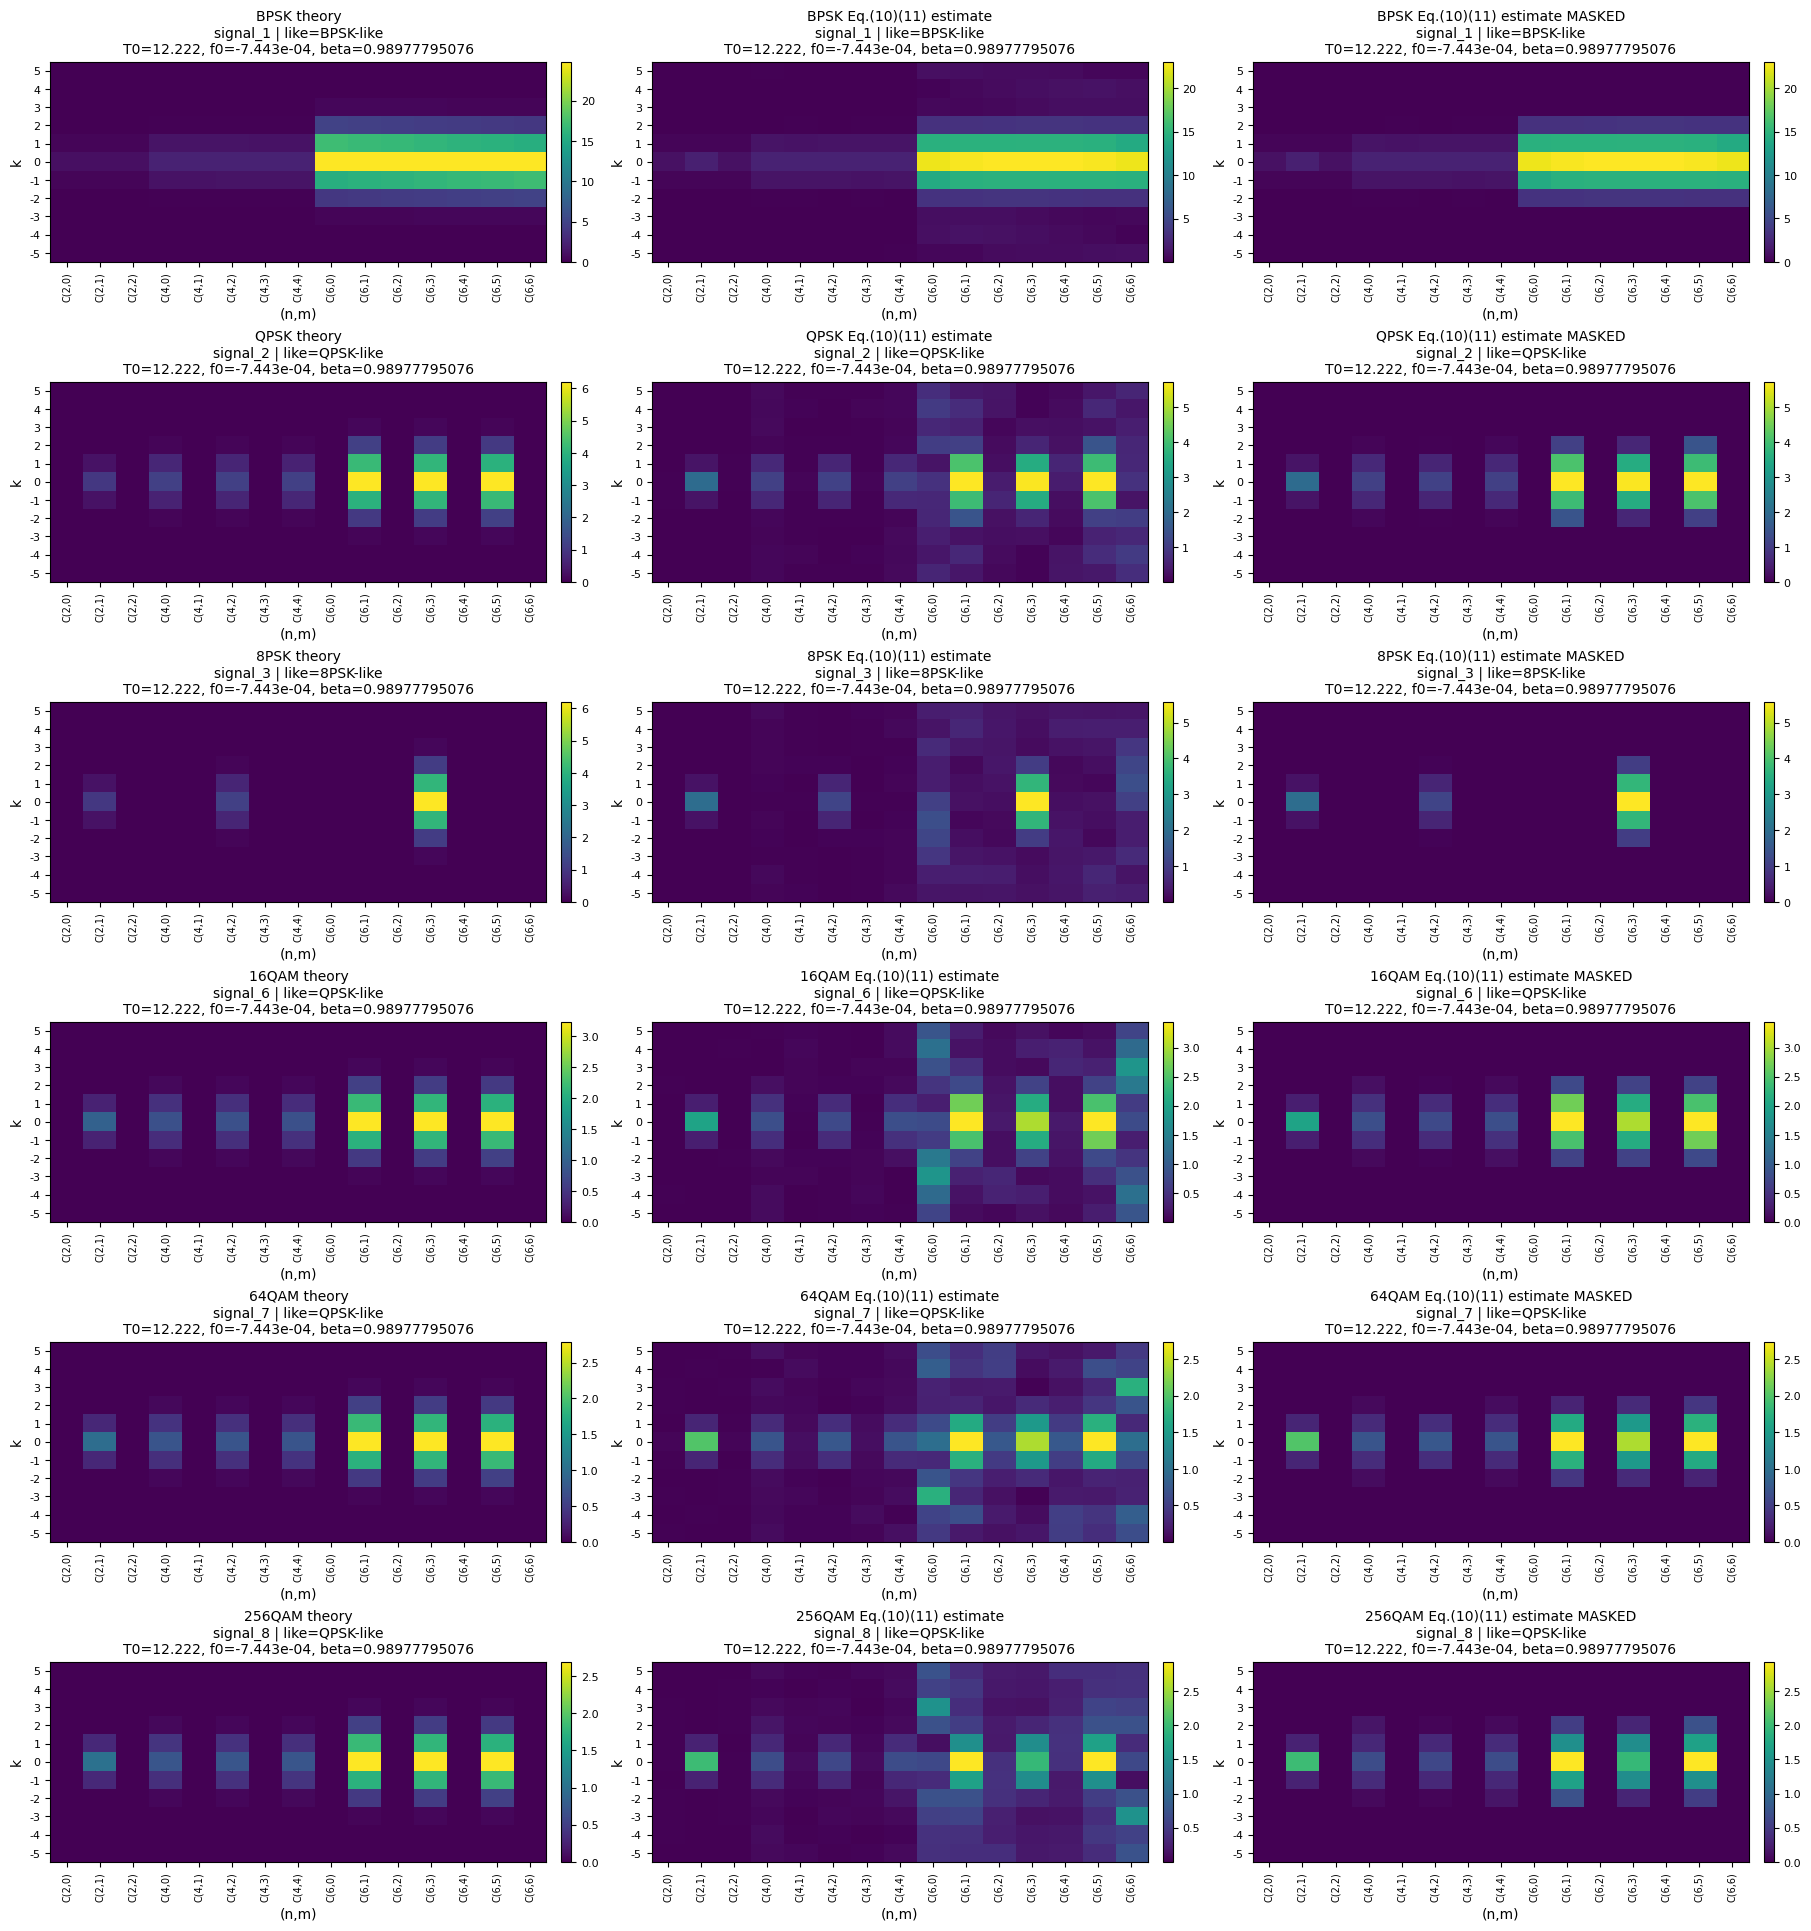


================ BPSK theory matrix =================


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)"
-5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000002,0.000003,0.000003,0.000004,0.000005,0.000006,0.000007
-4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005644,0.006219,0.006844,0.007525,0.008265,0.009069,0.009941
-3,0.000001,0.000000,0.000000,0.001474,0.001676,0.001902,0.002152,0.002429,0.344931,0.365088,0.386224,0.408374,0.431576,0.455867,0.481286
-2,0.000000,0.000004,0.000005,0.150983,0.159391,0.168144,0.177251,0.186717,4.013965,4.150985,4.291167,4.434523,4.581066,4.730804,4.883744
-1,0.300902,0.315059,0.329478,1.209667,1.238333,1.267104,1.295960,1.324879,15.604475,15.857536,16.110003,16.361728,16.612562,16.862355,17.110957
0,0.999595,1.000000,0.999595,2.334389,2.335780,2.336243,2.335780,2.334389,24.822805,24.839826,24.850045,24.853452,24.850045,24.839826,24.822805
1,0.329478,0.315059,0.300902,1.324879,1.295960,1.267104,1.238333,1.209667,17.110957,16.862355,16.612562,16.361728,16.110003,15.857536,15.604475
2,0.000005,0.000004,0.000000,0.186717,0.177251,0.168144,0.159391,0.150983,4.883744,4.730804,4.581066,4.434523,4.291167,4.150985,4.013965
3,0.000000,0.000000,0.000001,0.002429,0.002152,0.001902,0.001676,0.001474,0.481286,0.455867,0.431576,0.408374,0.386224,0.365088,0.344931
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.009941,0.009069,0.008265,0.007525,0.006844,0.006219,0.005644



================ BPSK Eq.(10)(11) estimate matrix =================


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)"
-5,0.021485,0.013581,0.015851,0.040976,0.046821,0.047831,0.080476,0.107663,0.416080,0.446404,0.675015,0.780950,0.786497,0.844102,0.972141
-4,0.000442,0.015495,0.008237,0.039109,0.066575,0.057959,0.028639,0.076604,0.909811,1.110550,0.995479,0.822275,0.680371,0.467485,0.230191
-3,0.008578,0.006032,0.007200,0.089427,0.062035,0.057668,0.047773,0.016561,0.826242,0.863597,0.821790,0.656133,0.535555,0.391692,0.480942
-2,0.006584,0.006595,0.007189,0.142372,0.103601,0.089990,0.096590,0.056588,3.388678,3.399293,3.494514,3.443868,3.365874,3.266714,3.248619
-1,0.282195,0.284783,0.300910,1.187316,1.191974,1.191839,1.169714,1.180463,14.117506,14.598033,14.790278,14.854233,14.744408,14.715370,14.636418
0,1.002121,1.997303,1.002121,2.210242,2.215682,2.234564,2.215682,2.210242,22.435809,22.861564,23.049046,23.019227,23.049046,22.861564,22.435809
1,0.300910,0.284783,0.282195,1.180463,1.169714,1.191839,1.191974,1.187316,14.636418,14.715370,14.744408,14.854233,14.790278,14.598033,14.117506
2,0.007189,0.006595,0.006584,0.056588,0.096590,0.089990,0.103601,0.142372,3.248619,3.266714,3.365874,3.443868,3.494514,3.399293,3.388678
3,0.007200,0.006032,0.008578,0.016561,0.047773,0.057668,0.062035,0.089427,0.480942,0.391692,0.535555,0.656133,0.821790,0.863597,0.826242
4,0.008237,0.015495,0.000442,0.076604,0.028639,0.057959,0.066575,0.039109,0.230191,0.467485,0.680371,0.822275,0.995479,1.110550,0.909811



================ BPSK absolute error (theory vs estimate) =================


...

,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)"
-5,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000001,0.0
-4,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000674,0.0,0.000816,0.0,0.000983,0.0
-3,0.0,0.000000,0.0,0.000446,0.0,0.000575,0.0,0.000734,0.0,0.039579,0.0,0.044271,0.0,0.049420,0.0
-2,0.0,0.000004,0.0,0.045650,0.0,0.050839,0.0,0.056455,0.0,0.450001,0.0,0.480739,0.0,0.512858,0.0
-1,0.0,0.315059,0.0,0.365746,0.0,0.383113,0.0,0.400581,0.0,1.719089,0.0,1.773747,0.0,1.828019,0.0
0,0.0,1.000000,0.0,0.705809,0.0,0.706370,0.0,0.705809,0.0,2.692843,0.0,2.694321,0.0,2.692843,0.0
1,0.0,0.315059,0.0,0.400581,0.0,0.383113,0.0,0.365746,0.0,1.828019,0.0,1.773747,0.0,1.719089,0.0
2,0.0,0.000004,0.0,0.056455,0.0,0.050839,0.0,0.045650,0.0,0.512858,0.0,0.480739,0.0,0.450001,0.0
3,0.0,0.000000,0.0,0.000734,0.0,0.000575,0.0,0.000446,0.0,0.049420,0.0,0.044271,0.0,0.039579,0.0
4,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000983,0.0,0.000816,0.0,0.000674,0.0



================ 256QAM Eq.(10)(11) estimate matrix =================


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)"
-5,0.007409,0.005647,0.003738,0.074559,0.053757,0.019446,0.031222,0.073184,0.405306,0.381660,0.383186,0.189621,0.208264,0.375694,0.739085
-4,0.012876,0.011610,0.007982,0.085196,0.021106,0.024098,0.011071,0.035054,0.418273,0.406295,0.248153,0.183735,0.194204,0.478928,0.562718
-3,0.022514,0.012452,0.013344,0.051304,0.008079,0.052666,0.039372,0.079819,0.557331,0.592461,0.261278,0.133684,0.139228,0.383334,1.489381
-2,0.018255,0.001174,0.017248,0.072363,0.025931,0.036291,0.055084,0.163255,0.728125,0.729506,0.407505,0.299805,0.216747,0.529704,0.727091
-1,0.002820,0.280621,0.019342,0.360102,0.053558,0.332023,0.043162,0.323267,0.364516,1.681625,0.418694,1.440398,0.205123,1.461520,0.106749
0,0.016517,2.003370,0.016517,0.684403,0.090280,0.629030,0.090280,0.684403,0.641065,2.929112,0.412349,1.961050,0.412349,2.929112,0.641065
1,0.019342,0.280621,0.002820,0.323267,0.043162,0.332023,0.053558,0.360102,0.106749,1.461520,0.205123,1.440398,0.418694,1.681625,0.364516
2,0.017248,0.001174,0.018255,0.163255,0.055084,0.036291,0.025931,0.072363,0.727091,0.529704,0.216747,0.299805,0.407505,0.729506,0.728125
3,0.013344,0.012452,0.022514,0.079819,0.039372,0.052666,0.008079,0.051304,1.489381,0.383334,0.139228,0.133684,0.261278,0.592461,0.557331
4,0.007982,0.011610,0.012876,0.035054,0.011071,0.024098,0.021106,0.085196,0.562718,0.478928,0.194204,0.183735,0.248153,0.406295,0.418273



================ 256QAM absolute error (theory vs estimate) =================


,"C(2,0)","C(2,1)","C(2,2)","C(4,0)","C(4,1)","C(4,2)","C(4,3)","C(4,4)","C(6,0)","C(6,1)","C(6,2)","C(6,3)","C(6,4)","C(6,5)","C(6,6)"
-5,0.007409,0.005647,0.003738,0.074559,0.053757,0.019446,0.031222,0.073184,0.405306,0.381660,0.383186,0.189621,0.208264,0.375693,0.739085
-4,0.012876,0.011610,0.007982,0.085196,0.021106,0.024098,0.011071,0.035054,0.418273,0.405621,0.248153,0.182919,0.194204,0.477945,0.562718
-3,0.022514,0.012452,0.013344,0.050858,0.008079,0.052091,0.039372,0.079085,0.557331,0.552882,0.261278,0.089413,0.139228,0.333914,1.489381
-2,0.018255,0.001170,0.017248,0.026713,0.025931,0.014548,0.055084,0.106800,0.728125,0.279505,0.407505,0.180934,0.216747,0.016846,0.727091
-1,0.002820,0.034438,0.019342,0.005644,0.053558,0.051090,0.043162,0.077314,0.364516,0.037464,0.418694,0.333349,0.205123,0.366499,0.106749
0,0.016517,1.003370,0.016517,0.021406,0.090280,0.077340,0.090280,0.021406,0.641065,0.236269,0.412349,0.733271,0.412349,0.236269,0.641065
1,0.019342,0.034438,0.002820,0.077314,0.043162,0.051090,0.053558,0.005644,0.106749,0.366499,0.205123,0.333349,0.418694,0.037464,0.364516
2,0.017248,0.001170,0.018255,0.106800,0.055084,0.014548,0.025931,0.026713,0.727091,0.016846,0.216747,0.180934,0.407505,0.279505,0.728125
3,0.013344,0.012452,0.022514,0.079085,0.039372,0.052091,0.008079,0.050858,1.489381,0.333914,0.139228,0.089413,0.261278,0.552882,0.557331
4,0.007982,0.011610,0.012876,0.035054,0.011071,0.024098,0.021106,0.085196,0.562718,0.477945,0.194204,0.182919,0.248153,0.405621,0.418273


In [7]:
import os
import math
from functools import lru_cache
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
# ============================================================
# Config
# ============================================================
USE_GPU = True
TORCH_DEVICE = "cuda:1" if (USE_GPU and torch.cuda.is_available()) else "cpu"
TORCH_COMPLEX = torch.complex128   
TORCH_REAL = torch.float64
print(f"Using device: {TORCH_DEVICE}")
# ============================================================
# Dataset switch
# ============================================================
DATASET_NAME = "2018"   # "2022" or "2018"
ROOT_MAP = {
    "2022": "../../../CSPB.ML_dataset/CSPB_ML_2022_Data",
    "2018": "../../../CSPB.ML_dataset/CSPB_ML_2018_Data",
}

if DATASET_NAME not in ROOT_MAP:
    raise ValueError(f"Unsupported DATASET_NAME: {DATASET_NAME}")
ROOT_DATA = ROOT_MAP[DATASET_NAME]

FS_IN = 1.0              # dataset sampling frequency is normalized to 1
N_PER_BATCH = 4000
N_BATCHES = 28
N_TOTAL = N_PER_BATCH * N_BATCHES  # 112000
SAMPLES_PER_SIG = 32768
EPS = 1e-12
def to_torch_complex(x, device=TORCH_DEVICE):
    if isinstance(x, torch.Tensor):
        return x.to(device=device, dtype=TORCH_COMPLEX)
    x = np.asarray(x)
    x = np.ascontiguousarray(x)
    return torch.as_tensor(x, dtype=TORCH_COMPLEX, device=device)
def torch_complex_to_numpy(x):
    """
    torch tensor -> numpy
    """
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return x 

LABEL_MAP = {
    "2022": "CSPB_ML_2022_Signal_Truth_Labels.txt",
    "2018": "CSPB_ML_2018_Signal_Truth_Labels.txt",
}
LABEL_PATH = os.path.join(ROOT_DATA, LABEL_MAP[DATASET_NAME])
# ============================================================
# Truth labels
# ============================================================
def load_truth_labels(label_path: str) -> pd.DataFrame:
    """
    Read the truth-label txt file.

    Expected columns:
      SignalIndex  SignalType  BaseSymbolPeriod  CarrierOffset
      ExcessBandwidth  UpsampleFactor  DownsampleFactor
      InbandSNRdB  NoiseSpectralDensitydB
    """
    df = pd.read_csv(label_path, delim_whitespace=True)
    expected = [
        "SignalIndex", "SignalType", "BaseSymbolPeriod", "CarrierOffset",
        "ExcessBandwidth", "UpsampleFactor", "DownsampleFactor",
        "InbandSNRdB", "NoiseSpectralDensitydB"
    ]
    if list(df.columns) != expected:
        raise ValueError(
            f"Unexpected label columns.\n"
            f"Got     : {list(df.columns)}\n"
            f"Expected: {expected}"
        )

    # Normalize string type
    df["SignalType"] = df["SignalType"].astype(str).str.lower()

    # Handle the known edge case: DownsampleFactor==0 means no resampling => D=1
    D = df["DownsampleFactor"].to_numpy(dtype=np.float64)
    U = df["UpsampleFactor"].to_numpy(dtype=np.float64)
    Tbase = df["BaseSymbolPeriod"].to_numpy(dtype=np.float64)

    D_eff = np.where(D == 0, 1.0, D)
    U_eff = np.where(U == 0, 1.0, U)

    # Symbol rate in normalized units (cycles/sample)
    # Rs = (1 / BaseSymbolPeriod) * (D / U)
    Rs = D_eff / (U_eff * Tbase)
    T0_eff = 1.0 / Rs

    df["SymbolRate"] = Rs
    df["T0_eff"] = T0_eff
    df["CFO"] = df["CarrierOffset"].astype(np.float64)
    return df

TRUTH_DF = load_truth_labels(LABEL_PATH)
TRUTH_DF = TRUTH_DF.set_index("SignalIndex", drop=False)

def signal_type_to_pattern_hint(sig_type: str) -> str:
    """
    Pattern hint derived from modulation label.
    This is metadata only here; computation below uses the full 11x25 fixed grid.

    Paper says:
      - BPSK / ASK / OOK -> BPSK-like
      - symmetric QAM (>2 points) -> QPSK-like
      - other listed patterns: QPSK-like, pi/4-DQPSK-like, 8PSK-like, SQPSK-like

    For MSK, the paper's five-pattern list does not explicitly say "MSK-like".
    We keep it as an explicit hint string instead of forcing a possibly wrong mapping.
    """
    sig_type = sig_type.lower()
    if sig_type == "bpsk":
        return "BPSK-like"
    if sig_type == "qpsk":
        return "QPSK-like"
    if sig_type == "8psk":
        return "8PSK-like"
    if sig_type == "dqpsk":
        return "pi/4-DQPSK-like"
    if sig_type in {"16qam", "64qam", "256qam"}:
        return "QPSK-like"
    if sig_type == "msk":
        return "SQPSK-like"
    return "Unknown"

def get_truth_params(signal_index: int):
    if signal_index not in TRUTH_DF.index:
        raise ValueError(f"Signal index {signal_index} not found in truth labels.")
    row = TRUTH_DF.loc[signal_index]
    return {
        "signal_index": int(row["SignalIndex"]),
        "signal_type": str(row["SignalType"]),
        "pattern_hint": signal_type_to_pattern_hint(str(row["SignalType"])),
        "T0": float(row["T0_eff"]),
        "symbol_rate": float(row["SymbolRate"]),   # cycles/sample
        "f0": float(row["CFO"]),                   # cycles/sample
        "base_symbol_period": float(row["BaseSymbolPeriod"]),
        "upsample": float(row["UpsampleFactor"]),
        "downsample": float(row["DownsampleFactor"]),
        "snr_db": float(row["InbandSNRdB"]),
        "excess_bw": float(row["ExcessBandwidth"]),
    }


def global_to_path_and_type(gidx: int):
    """
    1-based global index -> file path
    Uses DATASET_NAME to choose 2018 or 2022.
    """
    if gidx < 1 or gidx > N_TOTAL:
        raise ValueError(f"global index out of range: {gidx} (valid 1..{N_TOTAL})")

    batch_dir = (gidx - 1) // N_PER_BATCH + 1
    tim_path = os.path.join(ROOT_DATA, f"Batch_Dir_{batch_dir}", f"signal_{gidx}.tim")
    return tim_path, batch_dir

def tim_to_complex_iq_32768(tim_path: str) -> np.ndarray:
    """
    Read one .tim file:
      first 2 float32 are metadata,
      then 32768 complex samples stored as interleaved float32 I,Q.
    """
    raw = np.fromfile(tim_path, dtype=np.float32)
    need = 2 + 2 * SAMPLES_PER_SIG
    if raw.size < need:
        raise ValueError(f"{tim_path}: {raw.size} floats < {need}")
    iq = raw[2:need]
    I = iq[0::2].astype(np.float64)
    Q = iq[1::2].astype(np.float64)
    x = I + 1j * Q
    if x.size != SAMPLES_PER_SIG:
        raise ValueError(f"{tim_path}: expected {SAMPLES_PER_SIG} IQ samples, got {x.size}")
    return x


# ============================================================
# Compare theory vs Eq.(10)(11) estimate on first 8 CSPB.ML.2018 signals
# Assumes the previous code cells have already been run.
# No repeated function definitions.
# ============================================================

ROOT_DATA = ROOT_MAP[DATASET_NAME]
LABEL_PATH = os.path.join(ROOT_DATA, LABEL_MAP[DATASET_NAME])

TRUTH_DF = load_truth_labels(LABEL_PATH).set_index("SignalIndex", drop=False)

# first 8 signals in CSPB.ML.2018; drop dqpsk / msk => keep 6 classes
FIRST8 = list(range(1, 9))
SKIP_TYPES = {"dqpsk", "msk"}

THEORY_NAME_MAP = {
    "bpsk":   "BPSK",
    "qpsk":   "QPSK",
    "8psk":   "8PSK",
    "16qam":  "16QAM",
    "64qam":  "64QAM",
    "256qam": "256QAM",
}
# =========================
# masks
# =========================
bpsk = [
    (0,4), (0,5), (0,6),
    (1,4), (1,5), (1,6),
    (2,4), (2,5), (2,6),
    (3,3), (3,4), (3,5), (3,6), (3,7),
    (4,3), (4,4), (4,5), (4,6), (4,7),
    (5,3), (5,4), (5,5), (5,6), (5,7),
    (6,3), (6,4), (6,5), (6,6), (6,7),
    (7,3), (7,4), (7,5), (7,6), (7,7),
    (8,3), (8,4), (8,5), (8,6), (8,7),
    (9,3), (9,4), (9,5), (9,6), (9,7),
    (10,3), (10,4), (10,5), (10,6), (10,7),
    (11,3), (11,4), (11,5), (11,6), (11,7),
    (12,3), (12,4), (12,5), (12,6), (12,7),
    (13,3), (13,4), (13,5), (13,6), (13,7),
    (14,3), (14,4), (14,5), (14,6), (14,7),
    (15,2), (15,3), (15,4), (15,5), (15,6), (15,7), (15,8),
    (16,2), (16,3), (16,4), (16,5), (16,6), (16,7), (16,8),
    (17,2), (17,3), (17,4), (17,5), (17,6), (17,7), (17,8),
    (18,2), (18,3), (18,4), (18,5), (18,6), (18,7), (18,8),
    (19,2), (19,3), (19,4), (19,5), (19,6), (19,7), (19,8),
    (20,2), (20,3), (20,4), (20,5), (20,6), (20,7), (20,8),
    (21,2), (21,3), (21,4), (21,5), (21,6), (21,7), (21,8),
    (22,2), (22,3), (22,4), (22,5), (22,6), (22,7), (22,8),
    (23,2), (23,3), (23,4), (23,5), (23,6), (23,7), (23,8),
]

qpsk = [
    (1,4), (1,5), (1,6),
    (3,3), (3,4), (3,5), (3,6), (3,7),
    (5,3), (5,4), (5,5), (5,6), (5,7),
    (7,3), (7,4), (7,5), (7,6), (7,7),
    (9,3), (9,4), (9,5), (9,6), (9,7),
    (11,3), (11,4), (11,5), (11,6), (11,7),
    (13,3), (13,4), (13,5), (13,6), (13,7),
    (15,2), (15,3), (15,4), (15,5), (15,6), (15,7), (15,8),
    (17,2), (17,3), (17,4), (17,5), (17,6), (17,7), (17,8),
    (19,2), (19,3), (19,4), (19,5), (19,6), (19,7), (19,8),
    (21,2), (21,3), (21,4), (21,5), (21,6), (21,7), (21,8),
    (23,2), (23,3), (23,4), (23,5), (23,6), (23,7), (23,8),
]

psk8 = [
    (1,4), (1,5), (1,6),
    (5,3), (5,4), (5,5), (5,6), (5,7),
    (11,3), (11,4), (11,5), (11,6), (11,7),
    (15,2), (15,3), (15,4), (15,5), (15,6), (15,7), (15,8),
    (19,2), (19,3), (19,4), (19,5), (19,6), (19,7), (19,8),
    (23,2), (23,3), (23,4), (23,5), (23,6), (23,7), (23,8),
]

dqpsk = [
    (1,3), (1,5), (1,7),
    (3,2), (3,4), (3,6), (3,8),
    (5,3), (5,5), (5,7),
    (7,2), (7,4), (7,6), (7,8),
    (9,2), (9,4), (9,6), (9,8),
    (11,1), (11,3), (11,5), (11,7), (11,9),
    (13,2), (13,4), (13,6), (13,8),
    (15,1), (15,3), (15,5), (15,7), (15,9),
    (17,0), (17,2), (17,4), (17,6), (17,8), (17,10),
    (19,1), (19,3), (19,5), (19,7), (19,9),
    (21,0), (21,2), (21,4), (21,6), (21,8), (21,10),
    (23,1), (23,3), (23,5), (23,7), (23,9),
]

sqpsk = [
    (0,4), (0,6),
    (1,5),
    (2,4), (2,6),
    (3,3), (3,5), (3,7),
    (4,4), (4,6),
    (5,3), (5,5), (5,7),
    (6,4), (6,6),
    (7,3), (7,5), (7,7),
    (8,4), (8,6),
    (9,3), (9,5), (9,7),
    (10,4), (10,6),
    (11,3), (11,5), (11,7),
    (12,4), (12,6),
    (13,3), (13,5), (13,7),
    (14,4), (14,6),
    (15,3), (15,5), (15,7),
    (16,2), (16,4), (16,6), (16,8),
    (17,3), (17,5), (17,7),
    (18,2), (18,4), (18,6), (18,8),
    (19,3), (19,5), (19,7),
    (20,2), (20,4), (20,6), (20,8),
    (21,3), (21,5), (21,7),
    (22,2), (22,4), (22,6), (22,8),
    (23,3), (23,5), (23,7),
]
MASK_W = 24
MASK_H = 11
import numpy as np
import matplotlib.pyplot as plt
def coords_to_mask(coords, width=MASK_W, height=MASK_H):
    mask = np.zeros((height, width), dtype=np.float64)
    for x, y in coords:
        if 0 <= x < width and 0 <= y < height:
            mask[y, x] = 1.0
    return mask

MASK_BPSK  = coords_to_mask(bpsk)
MASK_QPSK  = coords_to_mask(qpsk)
MASK_8PSK  = coords_to_mask(psk8)
MASK_DQPSK = coords_to_mask(dqpsk)
MASK_SQPSK = coords_to_mask(sqpsk)

MASK_BY_LIKE = {
    "BPSK-like": MASK_BPSK,
    "QPSK-like": MASK_QPSK,
    "8PSK-like": MASK_8PSK,
    "pi/4-DQPSK-like": MASK_DQPSK,
    "SQPSK-like": MASK_SQPSK,
}

def signal_type_to_like_name(sig_type: str) -> str:
    sig_type = str(sig_type).lower()
    if sig_type == "bpsk":
        return "BPSK-like"
    elif sig_type == "qpsk":
        return "QPSK-like"
    elif sig_type == "8psk":
        return "8PSK-like"
    elif sig_type == "dqpsk":
        return "pi/4-DQPSK-like"
    elif sig_type == "msk":
        return "SQPSK-like"
    elif sig_type in {"16qam", "64qam", "256qam"}:
        return "QPSK-like"
    else:
        return None
selected = []
for gidx in FIRST8:
    truth = get_truth_params(gidx)
    sig_type = truth["signal_type"].lower()
    if sig_type in SKIP_TYPES:
        continue
    selected.append((gidx, sig_type, truth))

print("Selected signals:")
for gidx, sig_type, truth in selected:
    print(
        f"  signal_{gidx}: {sig_type} | "
        f"T0={truth['T0']:.6f}, f0={truth['f0']:.6e}, beta={truth['excess_bw']}"
    )


# ============================================================
# continuation only: build cases -> plot 3 figures per class
# -> show unmasked numeric matrices
# ============================================================

def get_mask_11x15_for_signal_type(sig_type: str):
    like_name = signal_type_to_like_name(sig_type)
    if like_name is None:
        return np.ones((11, 15), dtype=np.float64), "Unknown"
    return MASK_BY_LIKE[like_name][:, :15], like_name


cases = []
for gidx, sig_type, truth in selected:
    tim_path, _ = global_to_path_and_type(gidx)
    x = tim_to_complex_iq_32768(tim_path)

    theory_name = THEORY_NAME_MAP[sig_type]

    theory = build_theoretical_cc_matrix_from_table3(
        pdf_name=theory_name,
        T0=truth["T0"],
        f0=truth["f0"],
        beta=truth["excess_bw"],
        span_symbols=12,
        pulse_sps=128,
    )

    estimate = build_estimated_cc_matrix_11x15_from_signal(
        x=x,
        T0=truth["T0"],
        f0=truth["f0"],
        remove_mean=False,
        max_k=5,
    )

    mask_11x15, like_name = get_mask_11x15_for_signal_type(sig_type)
    estimate_masked = estimate["matrix_abs"] * mask_11x15

    cases.append({
        "signal_index": gidx,
        "signal_type": sig_type,
        "theory_name": theory_name,
        "truth": truth,
        "theory": theory["matrix_abs"],
        "estimate": estimate["matrix_abs"],
        "estimate_masked": estimate_masked,
        "like_name": like_name,
    })


# ============================================================
# Plot: theory / unmasked Eq.(10)(11) / masked Eq.(10)(11)
# ============================================================
n_cases = len(cases)
fig, axes = plt.subplots(n_cases, 3, figsize=(18, 3.2 * n_cases), constrained_layout=True)

if n_cases == 1:
    axes = np.array([axes])

for i, case in enumerate(cases):
    mats = [
        (case["theory"],           f"{case['theory_name']} theory"),
        (case["estimate"],         f"{case['theory_name']} Eq.(10)(11) estimate"),
        (case["estimate_masked"],  f"{case['theory_name']} Eq.(10)(11) estimate MASKED"),
    ]

    for j, (M, title) in enumerate(mats):
        ax = axes[i, j]
        im = ax.imshow(M, aspect="auto", origin="lower")
        ax.set_title(
            f"{title}\n"
            f"signal_{case['signal_index']} | like={case['like_name']}\n"
            f"T0={case['truth']['T0']:.3f}, "
            f"f0={case['truth']['f0']:.3e}, "
            f"beta={case['truth']['excess_bw']}",
            fontsize=10
        )
        ax.set_xlabel("(n,m)")
        ax.set_ylabel("k")
        ax.set_xticks(np.arange(len(COL_LABELS_15)))
        ax.set_xticklabels(COL_LABELS_15, rotation=90, fontsize=7)
        ax.set_yticks(np.arange(len(K_LIST)))
        ax.set_yticklabels(K_LIST, fontsize=8)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cbar.ax.tick_params(labelsize=8)

plt.show()


# ============================================================
# Numeric matrices (NO MASK)
#   theory
#   Eq.(10)(11) estimate
#   absolute error (theory vs estimate)
# ============================================================
for case in cases:
    mod = case["theory_name"]

    theory_df = pd.DataFrame(
        case["theory"],
        index=K_LIST,
        columns=COL_LABELS_15
    ).round(6)

    estimate_df = pd.DataFrame(
        case["estimate"],
        index=K_LIST,
        columns=COL_LABELS_15
    ).round(6)

    abs_err_df = (theory_df - estimate_df).abs().round(6)

    print(f"\n================ {mod} theory matrix =================")
    display(theory_df)

    print(f"\n================ {mod} Eq.(10)(11) estimate matrix =================")
    display(estimate_df)

    print(f"\n================ {mod} absolute error (theory vs estimate) =================")
    display(abs_err_df)